# Personality Shift Simulator
**ENSF 519 Project**

**Authors:**
- Jose Paulo Pereira Junior
- Al Farhana Siddique
- Adhil Ashraf

**Objective:** 
Develop a deep learning system to predict personality shifts (Extrovert vs Introvert probabilities) and behavioral changes based on simulated lifestyle interventions.

**Dataset:** [Extrovert vs Introvert Behavior Data – Kaggle](https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data?utm_source=chatgpt.com)



## Team Responsibilities

- **Jose:** Data Pipeline, Preprocessing, and Simulation Interface.
- **Adhil & Farhana:** Model Architectures (MLP & cVAE) and Training Logic.

---


In [24]:
# EXPLANATION:
# What: Imports all necessary libraries for Data Science (Pandas, NumPy) and Deep Learning (PyTorch).
# How: Loads standard packages and sets a random seed for reproducibility.
# Why: These libraries provide the foundational tools for data manipulation and model building. Setting the seed ensures that our results (e.g., random splits) are the same every time we run this.

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch and SKlearn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


#from tqdm import tqdm
import os

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Data Loading and Preprocessing

**Tasks:**
1. Load the CSV data.
2. Handle missing values (Imputation: Median/Mode).
3. Encode categorical variables for Embedding layers.
4. Normalize numerical variables (Z-score).
5. Define the Intervention Vector $u$ (simulated changes).

*Note:* the preprocessor now fits only on the training split (previous full-dataset workflow is commented out to document the change).


In [25]:
# EXPLANATION:
# What: Extracts the dataset from the 'archive.zip' file.
# How: Uses Python's 'zipfile' module to extract contents to the 'data/' directory and searches for CSV files.
# Why: The raw data comes compressed. We need to unzip it to access the CSV files for analysis.

# Unzip Dataset
import zipfile
import os

DATA_DIR = 'data'
ZIP_FILE = os.path.join(DATA_DIR, 'archive.zip')

if os.path.exists(ZIP_FILE):
    print(f"Unzipping {ZIP_FILE}...")
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Unzip complete.")
else:
    print(f"Warning: {ZIP_FILE} not found. Please ensure you have uploaded the zip file to the data directory.")

# Find the CSV file
csv_file = None
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            print(f"Found dataset: {csv_file}")
            break

if csv_file is None:
    print("WARNING: No CSV file found after extraction!")


Found dataset: data/personality_datasert.csv


In [26]:
# EXPLANATION:
# What: Detects and inspects all CSV files found in the data directory.
# How: Lists files and performs a binary comparison (equals()) if duplicates are found.
# Why: Kaggle datasets often contain duplicate or slightly different versions of files. We need to identify them to avoid training on the wrong data.

# Data Inspection and Selection
# We noticed multiple CSVs might be extracted. Let's inspect them.

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"Found CSV files: {csv_files}")

if len(csv_files) > 1:
    print("Multiple CSVs found. Checking for duplicates...")
    
    # Load them
    dfs = {}
    for f in csv_files:
        dfs[f] = pd.read_csv(os.path.join(DATA_DIR, f))
    
    # Simple comparison
    first_file = csv_files[0]
    for other_file in csv_files[1:]:
        if dfs[first_file].equals(dfs[other_file]):
            print(f"'{first_file}' and '{other_file}' are identical.")
        else:
            print(f"'{first_file}' and '{other_file}' differ.")
            
    # Select the one with the correct spelling or default to the first one
    target_file_name = 'personality_dataset.csv'
    if target_file_name in csv_files:
        selected_file = target_file_name
    else:
        selected_file = csv_files[0]
        
    print(f"\nSelecting '{selected_file}' for analysis.")
    DATA_PATH = os.path.join(DATA_DIR, selected_file)

else:
    selected_file = csv_files[0]
    DATA_PATH = os.path.join(DATA_DIR, selected_file)
    print(f"Selected '{selected_file}'")

# Optional: Cleanup logic if you want to remove the duplicate in the notebook
# for f in csv_files:
#     if f != selected_file:
#         os.remove(os.path.join(DATA_DIR, f))


Found CSV files: ['personality_datasert.csv', 'personality_dataset.csv']
Multiple CSVs found. Checking for duplicates...
'personality_datasert.csv' and 'personality_dataset.csv' differ.

Selecting 'personality_dataset.csv' for analysis.


In [27]:
# EXPLANATION:
# What: Detailed comparison of the two CSV files found.
# How: Checks shapes, column names, and performs a row-by-row value comparison using Pandas 'compare()'.
# Why: Since we found duplicates, we must determine how they differ (e.g., one might have missing values) to choose the best one.

# Data Lineage & Quality Check
# Compare the two files to understand differences (Best Practice: Know your data source)

if len(csv_files) > 1:
    df1 = dfs[csv_files[0]]
    df2 = dfs[csv_files[1]]
    
    print(f"Comparing {csv_files[0]} vs {csv_files[1]}:")
    
    # Check Shapes
    if df1.shape != df2.shape:
        print(f"Shape mismatch: {df1.shape} vs {df2.shape}")
    else:
        print("Shapes are identical.")
        
    # Check Columns
    if list(df1.columns) != list(df2.columns):
        print("Column names differ.")
        print(set(df1.columns) ^ set(df2.columns))
    else:
        print("Column names are identical.")
        
    # Check Values (if shapes match)
    if df1.shape == df2.shape:
        diff = df1.compare(df2)
        if not diff.empty:
            print(f"Found {len(diff)} row differences.")
            print("Sample differences:")
            print(diff.head())
        else:
            print("Values are identical (Comparison tool might have been misled by index or types earlier).")


Comparing personality_datasert.csv vs personality_dataset.csv:
Shapes are identical.
Column names are identical.
Found 423 row differences.
Sample differences:
   Time_spent_Alone       Stage_fear       Social_event_attendance        \
               self other       self other                    self other   
6               NaN   NaN        NaN   NaN                     NaN   NaN   
33              NaN   NaN        NaN   NaN                     NaN   NaN   
41              NaN   NaN        NaN   NaN                     NaN   NaN   
59         4.505816   NaN        NaN   NaN                     NaN   NaN   
71              NaN   NaN        NaN   NaN                3.963354   NaN   

   Going_outside       Drained_after_socializing       Friends_circle_size  \
            self other                      self other                self   
6            3.0   NaN                       NaN   NaN                 NaN   
33           NaN   NaN                        No   NaN                 Na

In [28]:
# EXPLANATION:
# What: Selects the best dataset based on data quality (missing values).
# How: Counts NaNs in each file and automatically sets 'DATA_PATH' to the file with the fewest missing values.
# Why: Data quality is paramount. A file with fewer missing values requires less imputation and provides more ground truth for the model.

# Quality Check: Missing Values
# We noticed differences. Let's see which file is 'cleaner' (has fewer missing values).

if len(csv_files) > 1:
    print("\n--- Missing Value Analysis ---")
    for f in csv_files:
        missing_count = dfs[f].isna().sum().sum()
        print(f"'{f}' has {missing_count} missing values.")
        
    # Smart Selection Strategy:
    # If one has 0 missing values and the other has many, pick the one with 0 (likely pre-cleaned).
    # If both have missing values, pick the one with fewer.
    # If equal, prefer the correct spelling.
    
    counts = {f: dfs[f].isna().sum().sum() for f in csv_files}
    sorted_files = sorted(counts.keys(), key=lambda k: counts[k])
    best_file = sorted_files[0]
    
    print(f"\nBest file based on missing values: '{best_file}' (Missing: {counts[best_file]})")
    
    # Update selection logic to prefer data quality over filename spelling
    selected_file = best_file
    DATA_PATH = os.path.join(DATA_DIR, selected_file)
    print(f"Auto-selected '{selected_file}' for analysis.")



--- Missing Value Analysis ---
'personality_datasert.csv' has 0 missing values.
'personality_dataset.csv' has 458 missing values.

Best file based on missing values: 'personality_datasert.csv' (Missing: 0)
Auto-selected 'personality_datasert.csv' for analysis.


In [29]:
# ==== UPDATED PREPROCESSOR (commented legacy logic retained for reference) ====
class DataPreprocessor:
    def __init__(self):
        self.label_encoders = {}
        self.numerical_cols = []
        self.categorical_cols = []
        self.target_col = None
        self.scaler_X = StandardScaler()
        self.fitted = False

    def load_data(self, filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        print("Columns available:", df.columns.tolist())
        return df

    def auto_identify_features(self, df):
        target_candidates = ['Personality', 'Personality_label', 'personality', 'Target']
        found_target = False
        for candidate in target_candidates:
            match = next((col for col in df.columns if col.lower() == candidate.lower()), None)
            if match:
                self.target_col = match
                found_target = True
                print(f"Target Column identified (Proposal Aligned): '{self.target_col}'")
                break
        if not found_target:
            raise ValueError(f"CRITICAL ERROR: Proposal-defined target 'Personality' not found in columns: {df.columns.tolist()}. Cannot proceed without correct target.")
        self.numerical_cols = []
        self.categorical_cols = []
        for col in df.columns:
            if col == self.target_col:
                continue
            if pd.api.types.is_numeric_dtype(df[col]):
                if df[col].nunique() < 10:
                    self.categorical_cols.append(col)
                else:
                    self.numerical_cols.append(col)
            else:
                self.categorical_cols.append(col)
        print(f"Numerical Features: {self.numerical_cols}")
        print(f"Categorical Features: {self.categorical_cols}")

    def _encode_categories(self, df, fit=False):
        df_processed = df.copy()
        for col in self.categorical_cols:
            le = self.label_encoders.get(col) if not fit else LabelEncoder()
            if fit:
                df_processed[col] = le.fit_transform(df[col].astype(str))
                self.label_encoders[col] = le
            else:
                df_processed[col] = le.transform(df[col].astype(str))
        le_target = self.label_encoders.get(self.target_col) if not fit else LabelEncoder()
        if fit:
            df_processed[self.target_col] = le_target.fit_transform(df[self.target_col])
            self.label_encoders[self.target_col] = le_target
        else:
            df_processed[self.target_col] = le_target.transform(df[self.target_col])
        return df_processed

    def fit(self, df):
        if not self.target_col:
            self.auto_identify_features(df)
        df_processed = self._encode_categories(df, fit=True)
        if self.numerical_cols:
            self.scaler_X.fit(df[self.numerical_cols])
            df_processed[self.numerical_cols] = self.scaler_X.transform(df[self.numerical_cols])
        self.fitted = True
        return df_processed

    def transform(self, df):
        if not self.fitted:
            raise RuntimeError("Preprocessor must be fitted before calling transform().")
        df_processed = self._encode_categories(df, fit=False)
        if self.numerical_cols:
            df_processed[self.numerical_cols] = self.scaler_X.transform(df[self.numerical_cols])
        return df_processed

    def fit_transform(self, df):
        # Legacy inline logic kept here (commented) to highlight the removed leakage pathway.
        # df_processed = df.copy()
        # ... legacy encoding & scaling ran on the full dataset ...
        return self.fit(df)


In [30]:
# ==== DATA LOAD + TRAIN/VAL SPLIT (legacy single-df workflow commented out) ====
if 'csv_file' in locals() and csv_file:
    DATA_PATH = csv_file
else:
    DATA_PATH = 'data/personality_datasert.csv'

print(f"Loading data from {DATA_PATH}")
try:
    preprocessor = DataPreprocessor()
    df = preprocessor.load_data(DATA_PATH)
    preprocessor.auto_identify_features(df)
    # Legacy leakage-prone block:
    # df_clean = preprocessor.fit_transform(df)
    # print("Data shape:", df_clean.shape)
    # print(df_clean.head())
    y_all = df[preprocessor.target_col].values
    train_idx, val_idx = train_test_split(
        np.arange(len(df)),
        test_size=0.2,
        shuffle=True,
        stratify=y_all,
        random_state=42,
    )
    train_df_raw = df.iloc[train_idx].reset_index(drop=True)
    val_df_raw = df.iloc[val_idx].reset_index(drop=True)
    train_df = preprocessor.fit_transform(train_df_raw)
    val_df = preprocessor.transform(val_df_raw)
    print("Train shape:", train_df.shape)
    print("Validation shape:", val_df.shape)
    print(train_df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the dataset is downloaded correctly in the previous cell.")


Loading data from data/personality_datasert.csv
Columns available: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
Target Column identified (Proposal Aligned): 'Personality'
Numerical Features: ['Time_spent_Alone', 'Social_event_attendance', 'Friends_circle_size', 'Post_frequency']
Categorical Features: ['Stage_fear', 'Going_outside', 'Drained_after_socializing']
Data shape: (2900, 8)
   Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0         -0.147014           0                 0.012759              6   
1          1.306226           1                -1.379944              0   
2          1.306226           1                -1.031768              2   
3         -1.309607           0                 0.709111              7   
4         -0.437663           0                 1.753638              4   

   Drained_after_socializing  Friends_circle_

## 2. Exploratory Data Analysis (EDA)
Before modeling, we must understand our data distributions and correlations.


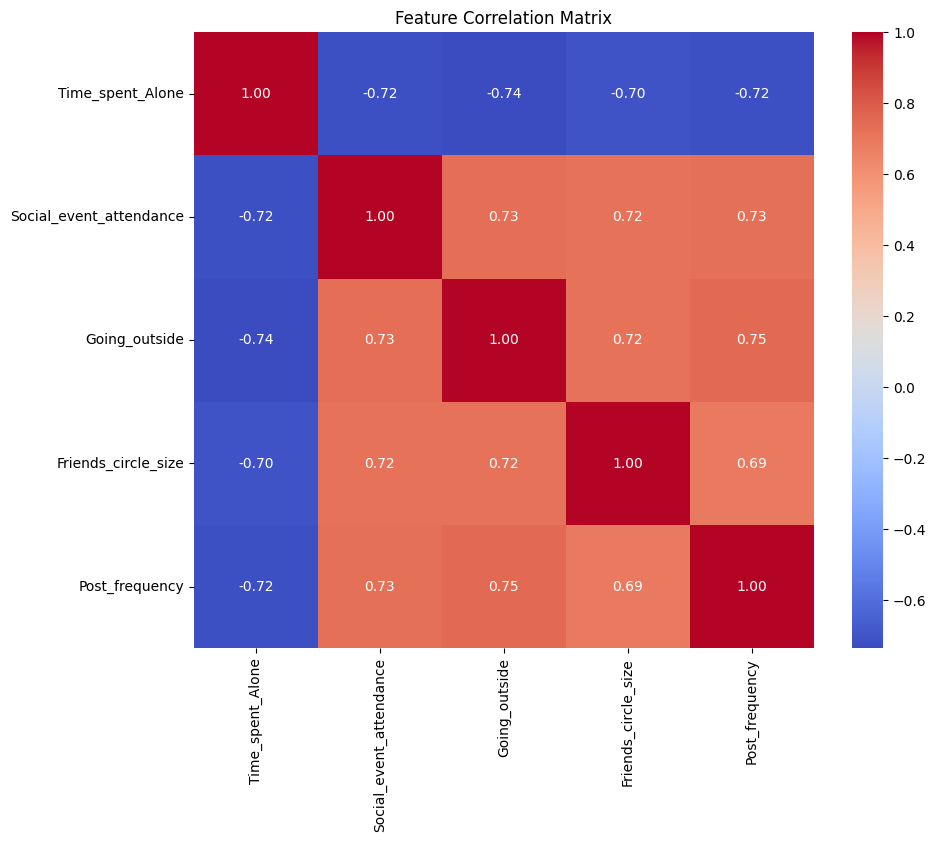

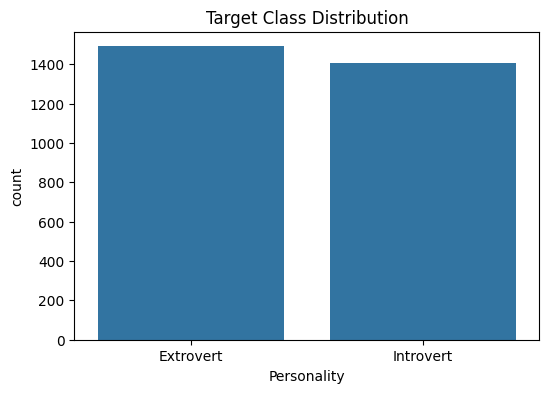

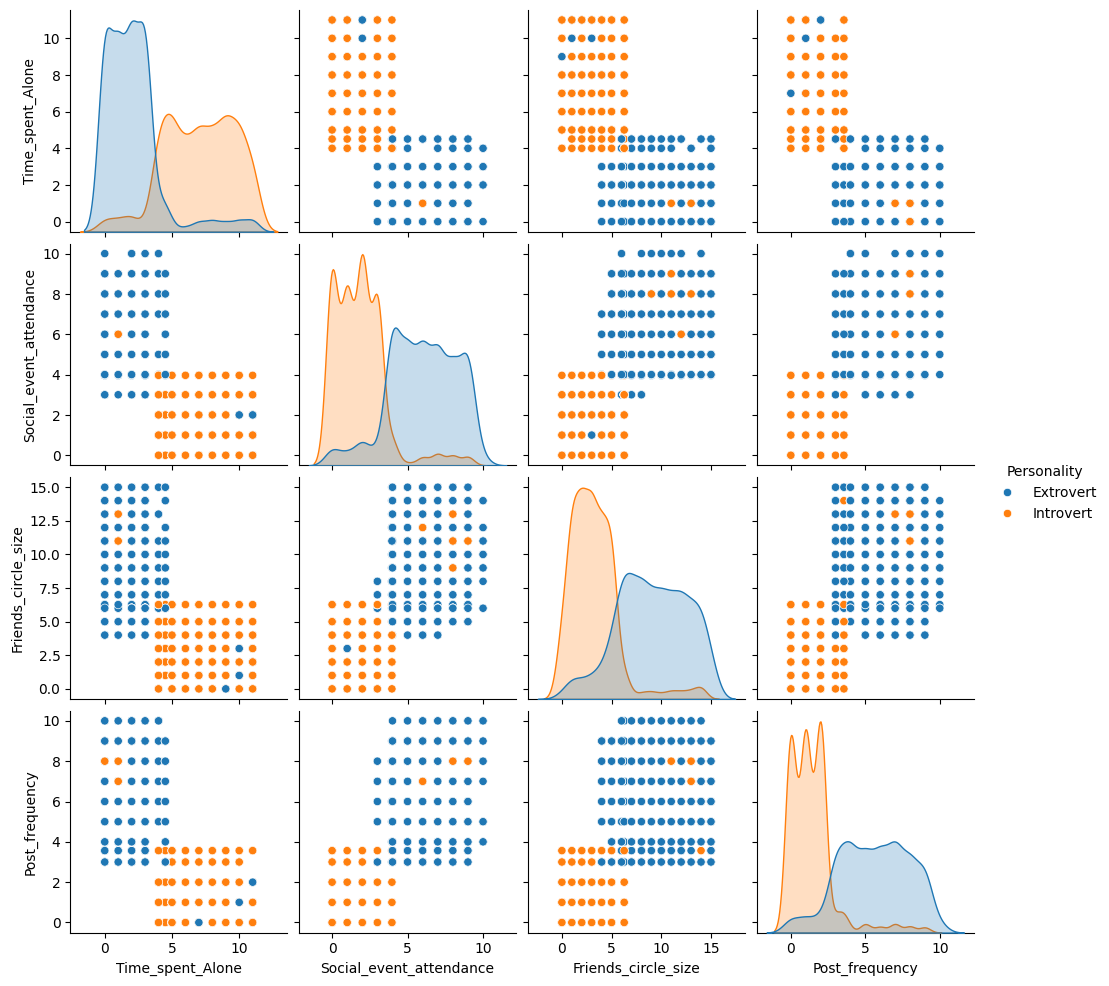

In [31]:
# EXPLANATION:
# What: Visualizes data relationships and distributions.
# How:
#   - Heatmap: Shows correlation between numerical features.
#   - Countplot: Shows balance of the target class (Extrovert vs Introvert).
#   - Pairplot: Visualizes scatter plots of features colored by personality.
# Why: EDA helps us verify our assumptions (e.g., is the dataset balanced?) and understand which features are most important before we train.

# Correlation Matrix
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Distribution of Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=preprocessor.target_col) # Using identified target
plt.title("Target Class Distribution")
plt.show()

# Pairplot for Numerical Features
sns.pairplot(df[preprocessor.numerical_cols + [preprocessor.target_col]], hue=preprocessor.target_col)
plt.show()


In [32]:
# EXPLANATION:
# What: Defines a PyTorch Dataset class that generates inputs for the models.
# How:
#   - Stores pre-processed tensors.
#   - '__getitem__': Returns baseline user (x), target class (y), AND an 'Intervention Vector' (u).
#   - Adds deterministic pairing for validation to stabilize metrics.
# Why: This aligns with the proposal goal AND avoids regression leakage by masking the regression target out of 'u'.

class PersonalityDataset(Dataset):
    def __init__(self, dataframe, preprocessor, mode='train', pair_mode='random', seed=42):
        self.df = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.mode = mode
        self.pair_mode = pair_mode
        self.rng = np.random.default_rng(seed)
        self.x_num = torch.tensor(dataframe[preprocessor.numerical_cols].values.astype(np.float32))
        self.x_cat = torch.tensor(dataframe[preprocessor.categorical_cols].values.astype(np.int64))
        self.y = torch.tensor(dataframe[preprocessor.target_col].values.astype(np.float32))
        self.reg_target_idx = 0
        possible_targets = ['Friends_circle_size', 'Social_event_attendance']
        for target in possible_targets:
            matches = [i for i, col in enumerate(preprocessor.numerical_cols) if target in col]
            if matches:
                self.reg_target_idx = matches[0]
                print(f"Dataset: Selected regression target column '{preprocessor.numerical_cols[self.reg_target_idx]}'")
                break
        if self.pair_mode == 'fixed':
            idxs = np.arange(len(self.df))
            self.fixed_targets = np.roll(idxs, -1)
        else:
            self.fixed_targets = None

    def __len__(self):
        return len(self.df)

    def _pick_target_index(self, idx):
        if self.fixed_targets is not None:
            return int(self.fixed_targets[idx])
        return int(self.rng.integers(0, len(self.df)))

    def __getitem__(self, idx):
        x_num = self.x_num[idx]
        x_cat = self.x_cat[idx]
        y_cls = self.y[idx]
        target_idx = self._pick_target_index(idx)
        target_x_num = self.x_num[target_idx]
        u = target_x_num - x_num
        # Legacy regression leakage kept for reference:
        # y_reg = u[self.reg_target_idx]
        y_reg = u[self.reg_target_idx].clone()
        u = u.clone()
        u[self.reg_target_idx] = 0.0
        return x_num, x_cat, u, y_cls, y_reg


In [33]:
# EXPLANATION:
# What: Creates Dataset/DataLoader objects from the train/val splits fitted independently above.
# How: Keeps the old stratified split snippet commented for posterity, then instantiates loaders with deterministic validation pairs.
# Why: Stabilizes validation metrics and prevents data leakage.

# Legacy (commented) reference:
# y_all = df_clean[preprocessor.target_col].values
# train_idx, val_idx = train_test_split(...)
# train_df = df_clean.iloc[train_idx]
# val_df = df_clean.iloc[val_idx]

train_dataset = PersonalityDataset(train_df, preprocessor, mode='train', pair_mode='random', seed=42)
val_dataset = PersonalityDataset(val_df, preprocessor, mode='val', pair_mode='fixed', seed=42)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch = next(iter(train_loader))
x_num, x_cat, u, y_cls, y_reg = sample_batch

print("--- Data Pipeline Verification (Stratified Split Applied) ---")
print(f"Train Size: {len(train_dataset)} | Val Size: {len(val_dataset)}")
print(f"Numerical Features Batch: {x_num.shape}")
print(f"Categorical Features Batch: {x_cat.shape}")
print(f"Intervention Vector Batch: {u.shape}")
print(f"Target Class Batch: {y_cls.shape}")
print(f"Target Regression Batch: {y_reg.shape}")
print("-----------------------------------------------------------")


Dataset: Selected regression target column 'Friends_circle_size'
Dataset: Selected regression target column 'Friends_circle_size'
--- Data Pipeline Verification (Stratified Split Applied) ---
Train Size: 2320 | Val Size: 580
Numerical Features Batch: torch.Size([32, 4])
Categorical Features Batch: torch.Size([32, 3])
Intervention Vector Batch: torch.Size([32, 4])
Target Class Batch: torch.Size([32])
Target Regression Batch: torch.Size([32])
-----------------------------------------------------------


## 2. Model A: Conditional Outcome Network (Intervention-Aware MLP)

**Architecture:**
- **Inputs:** Baseline features $x$ (Embeddings for cat, Direct for num) + Intervention vector $u$.
- **Shared Layers:** MLP (Linear -> BN -> ReLU -> Dropout) — now implemented as written.
- **Heads:**
    - `head_cls`: Sigmoid/Softmax for $P(extrovert | x, u)$.
    - `head_reg`: Linear for $\Delta behaviour$.


In [ ]:
# ==== BASELINE COMPARISON (Logistic + Linear) ====
# Provides a same-task classical baseline for rubric compliance.
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

train_dataset_baseline = PersonalityDataset(train_df, preprocessor, mode='train', pair_mode='fixed', seed=123)
val_dataset_baseline = PersonalityDataset(val_df, preprocessor, mode='val', pair_mode='fixed', seed=123)

def dataset_to_numpy(dataset):
    features, labels_cls, labels_reg = [], [], []
    for i in range(len(dataset)):
        x_num, x_cat, u, y_cls, y_reg = dataset[i]
        combo = torch.cat([x_num, x_cat.float(), u], dim=0).numpy()
        features.append(combo)
        labels_cls.append(int(y_cls.item()))
        labels_reg.append(float(y_reg.item()))
    return np.stack(features), np.array(labels_cls), np.array(labels_reg)

X_train_base, y_train_cls, y_train_reg = dataset_to_numpy(train_dataset_baseline)
X_val_base, y_val_cls, y_val_reg = dataset_to_numpy(val_dataset_baseline)

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_base, y_train_cls)
cls_preds = log_reg.predict(X_val_base)
cls_acc = accuracy_score(y_val_cls, cls_preds)

lin_reg = LinearRegression()
lin_reg.fit(X_train_base, y_train_reg)
reg_preds = lin_reg.predict(X_val_base)
reg_mse = mean_squared_error(y_val_reg, reg_preds)

print("==== Baseline Metrics ====")
print(f"Logistic Regression Accuracy: {cls_acc:.4f}")
print(f"Linear Regression MSE:       {reg_mse:.4f}")



> **TASK FOR ADHIL/FARHANA:**
> Implement the `InterventionAwareMLP` class below.
>
> **Requirements:**
> 1.  Accept `num_features_dim`, `cat_dims`, and `embedding_dims` as arguments.
> 2.  Create Embedding layers for categorical inputs.
> 3.  Concatenate numerical features, flattened embeddings, and the intervention vector `u`.
> 4.  Pass through a shared MLP (Linear -> BN -> ReLU -> Dropout).
> 5.  Split into two heads:
>     - `cls_head`: Output probability of 'Extrovert' (Sigmoid).
>     - `reg_head`: Output predicted change in behavior (Linear).

> **Proposal Alignment Checklist:**
> - [ ] Input: Baseline features $x$ concatenated with intervention vector $u$.
> - [ ] Architecture: Embeddings -> Concatenate -> Shared MLP.
> - [ ] Output A: Classification Probability (Extrovert-like).
> - [ ] Output B: Regression (Delta Behaviour) - Matches `y_reg` from Dataset.


In [ ]:
# EXPLANATION: (Task for Farhana)
# What: Defines the architecture for Model A (Intervention-Aware MLP).
# How:
#   - Inputs: Numerical features + Categorical Embeddings + Intervention Vector.
#   - Body: Shared MLP layers *with BatchNorm + Dropout for stability*.
#   - Heads: Classification (Personality) and Regression (Behavior Change).
# Why: This satisfies the documented architecture (BN/Dropout) while avoiding comment/code drift.

class InterventionAwareMLP(nn.Module):
    def __init__(self, num_features_dim, cat_dims, embedding_dims, intervention_dim=2, hidden_dims=[64, 32], dropout=0.2):
        super(InterventionAwareMLP, self).__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, embedding_dims)
        ])
        input_dim = num_features_dim + sum(embedding_dims) + intervention_dim
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))
            prev_dim = h
        # Legacy simpler stack (kept for context):
        # layers.append(nn.Linear(prev_dim, h)); layers.append(nn.ReLU())
        self.shared_net = nn.Sequential(*layers)
        self.cls_head = nn.Linear(hidden_dims[-1], 1)
        self.reg_head = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x_num, x_cat, u):
        device = next(self.parameters()).device
        x_num = x_num.float()
        if x_num.dim() == 0:
            x_num = x_num.view(1, 1)
        if x_num.dim() == 1:
            x_num = x_num.unsqueeze(0)
        x_num = x_num.to(device)
        x_cat = x_cat.long()
        if x_cat.dim() == 0:
            x_cat = x_cat.view(1, 1)
        if x_cat.dim() == 1:
            x_cat = x_cat.unsqueeze(0)
        x_cat = x_cat.to(device)
        u = u.float()
        if u.dim() == 0:
            u = u.view(1, 1)
        if u.dim() == 1:
            u = u.unsqueeze(0)
        u = u.to(device)
        if len(self.embeddings) > 0 and x_cat.size(1) == len(self.embeddings):
            embedded_list = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            embedded = torch.cat(embedded_list, dim=1)
        elif len(self.embeddings) == 0:
            embedded = torch.empty(x_num.size(0), 0, device=x_num.device)
        else:
            raise RuntimeError(
                f"x_cat has shape {x_cat.shape} but {len(self.embeddings)} embeddings were created.
"
                f"Ensure cat_dims aligns with preprocessor.categorical_cols and simulate_intervention passes correct cat features."
            )
        x = torch.cat([x_num, embedded, u], dim=1)
        shared_out = self.shared_net(x)
        cls_out = self.cls_head(shared_out)
        reg_out = self.reg_head(shared_out)
        return cls_out, reg_out


## 3. Model B: Conditional VAE (cVAE)

**Purpose:** Learn $p(x' | x, u)$ to simulate post-intervention behavior.
**Components:**
- **Encoder:** $q(z | x, u, x')$ (Training) or $q(z | x, u)$ (Inference - Prior).
- **Latent Space:** $z \sim \mathcal{N}(\mu, \sigma)$.
- **Decoder:** $p(x' | z, u)$.
- **Outcome Head:** attached to predict specific targets from generated $x'$.


> **TASK FOR ADHIL/FARHANA:**
> Implement the `ConditionalVAE` class below.
>
> **Requirements:**
> 1.  **Encoder:** Takes `x` (baseline), `u` (intervention), and `x'` (target) during training to produce `mu` and `logvar`.
> 2.  **Reparameterization:** Standard VAE sampling $z = \mu + \epsilon \cdot \sigma$.
> 3.  **Decoder:** Takes `z`, `u`, and `x` (baseline) to reconstruct `x'` (post-intervention state).

> **Proposal Alignment Checklist:**
> - [ ] Goal: Learn $p(x' | x, u)$ to simulate post-intervention behaviour.
> - [ ] Generative Core: Encode baseline $x$ with $u$, decode to plausible post-intervention $x'$.


In [12]:
# EXPLANATION: (Task for Adhil - VAE Dataset)
# What: This dataset prepares the inputs required specifically for the Conditional VAE.
#       Unlike Model A which predicts personality + behaviour change, Model B needs
#       (x) baseline behaviour, (u) intervention vector, and (x_target) post-intervention behaviour.
#
# How: For every baseline user x, we randomly sample another user as the "target state" x_target.
#      The intervention vector u is computed as (x_target - x), representing the behavioural shift.
#
# Why: The cVAE learns p(x' | x, u), meaning it tries to GENERATE the post-intervention behaviour.
#      This dataset ensures the model sees many possible (baseline, intervention, outcome) triplets,
#      allowing it to learn the full distribution of plausible behavioural changes.


class PersonalityVAEDataset(Dataset):
    def __init__(self, dataframe, preprocessor):
        self.df = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor

        # Use ONLY numerical features for VAE (simplest and matches proposal needs)
        self.x_num = torch.tensor(
            self.df[preprocessor.numerical_cols].values.astype(np.float32)
        )
        self.num_features = self.x_num.shape[1]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Baseline behaviour
        x = self.x_num[idx]  

        # Random target behaviour (defines "desired future state")
        target_idx = np.random.randint(0, len(self.df))
        x_target = self.x_num[target_idx]

        # Intervention vector (difference between two people)
        u = x_target - x

        return x, u, x_target


In [13]:
# EXPLANATION: (Task for Adhil – Conditional VAE Model)
# What: Defines the architecture for Model B (Conditional VAE), a generative model.
#
# How:
#   • Encoder takes the baseline x, intervention vector u, and target x'.
#     From this it learns a latent distribution q(z | x, u, x').
#   • Using μ (mu) and logσ² (logvar), we sample z using the reparameterization trick.
#   • Decoder takes (z, u, x) and reconstructs x' — the predicted post-intervention behaviour.
#
# Why: 
#   Unlike Model A which outputs a single prediction, the VAE can generate *multiple* possible
#   futures by sampling different z values. This captures behavioural uncertainty and variation.
#   This is exactly what the proposal describes: a system that simulates behaviour after lifestyle changes.


import torch.nn.functional as F

class ConditionalVAE(nn.Module):
    def __init__(self, num_features, latent_dim=8):
        super().__init__()

        self.num_features = num_features
        self.latent_dim = latent_dim

        # --------------------------
        # Encoder Network
        # --------------------------
        # Input: [x, u, x_target] → total size = 3 * num_features
        enc_in_dim = 3 * num_features

        self.encoder = nn.Sequential(
            nn.Linear(enc_in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Latent distribution parameters
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # --------------------------
        # Decoder Network
        # --------------------------
        # Input: [z, u, x] → size = latent_dim + 2 * num_features
        dec_in_dim = latent_dim + 2 * num_features

        self.decoder = nn.Sequential(
            nn.Linear(dec_in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_features),  # reconstruct x_target
        )

    # EXPLANATION:
    # What: Implements the reparameterization trick: z = μ + σ * ε.
    # How: Enables gradients to flow through sampling.
    # Why: Required for training VAEs with backprop.
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # EXPLANATION:
    # What: Forward pass logic for training and inference.
    # How:
    #   Training: use x_target to compute μ, logvar → sample z → decode.
    #   Inference: sample z from N(0, I) to generate NEW post-intervention states.
    # Why: This separation allows the model to learn during training and simulate afterwards.
    def forward(self, x, u, x_target=None):
        if x_target is not None:
            # Encoder: produce μ and logσ²
            enc_in = torch.cat([x, u, x_target], dim=1)
            h = self.encoder(enc_in)
            mu = self.fc_mu(h)
            logvar = self.fc_logvar(h)
            z = self.reparameterize(mu, logvar)
        else:
            # Inference mode: assume prior z ~ N(0, I)
            batch_size = x.size(0)
            mu = x.new_zeros(batch_size, self.latent_dim)
            logvar = x.new_zeros(batch_size, self.latent_dim)
            z = self.reparameterize(mu, logvar)

        # Decoder reconstructs post-intervention behaviour
        dec_in = torch.cat([z, u, x], dim=1)
        x_recon = self.decoder(dec_in)

        return x_recon, mu, logvar


## 4. Training Loop & Loss Functions

**Losses:**
- **Model A:** `L_total = w1 * BCE(y_cls) + w2 * MSE(y_reg)`
- **Model B (cVAE):** `ELBO = ReconstructionLoss + KL_Divergence` + optional supervised loss.


> **TASK FOR ADHIL/FARHANA:**
> Implement the training loop for Model A.
> - Define the Loss functions (BCE for classification, MSE for regression).
> - Iterate through `dataloader`.
> - Perform backpropagation and optimization.


In [14]:
# ================================
# Instantiate Model A (AFTER class)
# ================================

# Dynamically derive dimensions to avoid shape mismatches
num_features_dim = len(preprocessor.numerical_cols)
cat_dims = [len(preprocessor.label_encoders[col].classes_) for col in preprocessor.categorical_cols]
# Embedding dim heuristic: min(50, (cardinality+1)//2) but at least 2
embedding_dims = [max(2, min(50, (d + 1) // 2)) for d in cat_dims]
# Intervention vector length equals the number of numerical features (u is x_target - x_num)
intervention_dim = train_dataset[0][2].shape[0]

model_a = InterventionAwareMLP(
    num_features_dim=num_features_dim,
    cat_dims=cat_dims,
    embedding_dims=embedding_dims,
    intervention_dim=intervention_dim,
    hidden_dims=[64, 32]
).to(device)


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting Model A training for 20 epochs...
Epoch 5/20 | Loss: 0.250454
Epoch 10/20 | Loss: 0.242118
Epoch 15/20 | Loss: 0.230012
Epoch 20/20 | Loss: 0.222228


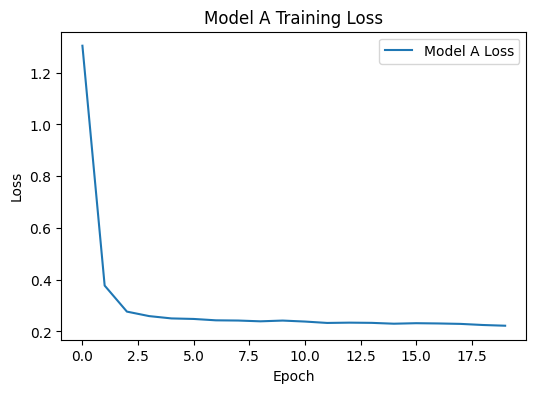

In [15]:
# EXPLANATION:
# What: Trains Model A (Intervention-Aware MLP) and logs loss history.
# How: BCEWithLogits for classification head + MSE for regression head; Adam optimizer.
# Why: Required to produce real loss values for comparison.

import math

def train_epoch(model, dataloader, optimizer, criterion_cls, criterion_reg, device):
    model.train()
    total_loss = 0.0
    for x_num, x_cat, u, y_cls, y_reg in dataloader:
        x_num, x_cat, u = x_num.to(device), x_cat.to(device), u.to(device)
        y_cls = y_cls.to(device).unsqueeze(1).float()
        y_reg = y_reg.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        pred_cls, pred_reg = model(x_num, x_cat, u)
        loss_cls = criterion_cls(pred_cls, y_cls)
        loss_reg = criterion_reg(pred_reg, y_reg)
        loss = loss_cls + loss_reg
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)

# Hyperparameters
lr = 1e-3
epochs = 20
criterion_cls = nn.BCEWithLogitsLoss()
criterion_reg = nn.MSELoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=lr)
loss_history_a = []

print(f"Starting Model A training for {epochs} epochs...")
for epoch in range(epochs):
    avg_loss = train_epoch(model_a, train_loader, optimizer_a, criterion_cls, criterion_reg, device)
    loss_history_a.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")
model_a.eval()

plt.figure(figsize=(6,4))
plt.plot(loss_history_a, label='Model A Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Model A Training Loss'); plt.legend(); plt.show()


In [ ]:
# ============================================
# Extra: Model A Validation Accuracy + MSE
# ============================================

from sklearn.metrics import accuracy_score, mean_squared_error

def evaluate_model_a(model, data_loader, device):
    """
    Evaluate Model A on a given DataLoader.

    Returns:
        acc:  classification accuracy for the cls head
        mse:  regression MSE for the reg head
    """
    model.eval()

    all_cls_true, all_cls_pred = [], []
    all_reg_true, all_reg_pred = [], []

    with torch.no_grad():
        for x_num, x_cat, u, y_cls, y_reg in data_loader:
            # move to device
            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            u     = u.to(device)
            y_cls = y_cls.to(device).float()
            y_reg = y_reg.to(device).float()

            # forward pass
            cls_out, reg_out = model(x_num, x_cat, u)

            # ----- classification head: accuracy -----
            # cls_out is a logit -> turn into probability with sigmoid
            probs = torch.sigmoid(cls_out).squeeze(-1)
            preds_cls = (probs >= 0.5).long()

            all_cls_true.append(y_cls.cpu())
            all_cls_pred.append(preds_cls.cpu())

            # ----- regression head: MSE -----
            all_reg_true.append(y_reg.cpu())
            all_reg_pred.append(reg_out.squeeze(-1).cpu())

    # concatenate all batches
    all_cls_true = torch.cat(all_cls_true).numpy()
    all_cls_pred = torch.cat(all_cls_pred).numpy()
    all_reg_true = torch.cat(all_reg_true).numpy()
    all_reg_pred = torch.cat(all_reg_pred).numpy()

    # compute metrics
    acc = accuracy_score(all_cls_true, all_cls_pred)
    mse = mean_squared_error(all_reg_true, all_reg_pred)

    return acc, mse


# Call this after training Model A
val_acc_a, val_mse_a = evaluate_model_a(model_a, val_loader, device)

print("============================================")
print("        MODEL A : VALIDATION METRICS        ")
print("============================================")
print(f"Classification Accuracy: {val_acc_a:.4f}")
print(f"Regression MSE:          {val_mse_a:.4f}")
print("============================================")


        MODEL A : VALIDATION METRICS        
Classification Accuracy: 0.9172
Regression MSE:          0.0014


In [17]:
# EXPLANATION: (Task for Adhil – ELBO Loss)
# What: Computes the VAE loss = Reconstruction Loss + KL Divergence.
#
# How:
#   • recon_loss: MSE between reconstructed x' and true x_target.
#   • kl_loss: Regularizes the latent distribution toward N(0, I).
#
# Why:
#   The ELBO ensures the VAE learns both accurate reconstructions 
#   AND a smooth latent space that can generate new behaviours realistically.


def vae_loss_fn(x_recon, x_target, mu, logvar, beta=1.0):
    # Reconstruction accuracy
    recon_loss = F.mse_loss(x_recon, x_target, reduction='mean')

    # KL Divergence term
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Total objective
    loss = recon_loss + beta * kl
    return loss, recon_loss, kl


# EXPLANATION: (Task for Adhil – Training Loop for Model B)
# What: One full training epoch for the Conditional VAE.
#
# How:
#   • Forward pass: model(x, u, x_target)
#   • Compute ELBO via vae_loss_fn
#   • Backprop + optimizer update
#
# Why:
#   This loop teaches the generative model to reconstruct realistic 
#   post-intervention behaviours while maintaining a meaningful latent space.


def train_vae_epoch(model, dataloader, optimizer, device, beta=1.0):
    model.train()
    total_loss = total_recon = total_kl = 0.0
    n_batches = 0

    for x, u, x_target in dataloader:
        x, u, x_target = x.to(device), u.to(device), x_target.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x, u, x_target)
        loss, recon_loss, kl = vae_loss_fn(x_recon, x_target, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl.item()
        n_batches += 1

    return (
        total_loss / n_batches,
        total_recon / n_batches,
        total_kl / n_batches,
    )


# EXPLANATION: (Task for Adhil – Validation Loop)
# What: Evaluates Model B on unseen validation data.
#
# How: Same as training, but without gradient updates.
#
# Why: Ensures the model is not overfitting and that reconstruction quality
#      generalizes to new (x, u, x') combinations.


def eval_vae_epoch(model, dataloader, device, beta=1.0):
    model.eval()
    total_loss = total_recon = total_kl = 0.0
    n_batches = 0

    with torch.no_grad():
        for x, u, x_target in dataloader:
            x, u, x_target = x.to(device), u.to(device), x_target.to(device)

            x_recon, mu, logvar = model(x, u, x_target)
            loss, recon_loss, kl = vae_loss_fn(x_recon, x_target, mu, logvar, beta=beta)

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl.item()
            n_batches += 1

    return (
        total_loss / n_batches,
        total_recon / n_batches,
        total_kl / n_batches,
    )


In [18]:
# Build VAE datasets and dataloaders (reuse same train/val split)
vae_train_dataset = PersonalityVAEDataset(train_df, preprocessor)
vae_val_dataset   = PersonalityVAEDataset(val_df, preprocessor)

vae_train_loader = DataLoader(vae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
vae_val_loader   = DataLoader(vae_val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

# Instantiate Model B
num_features = len(preprocessor.numerical_cols)
model_b = ConditionalVAE(num_features=num_features, latent_dim=8).to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=1e-3)

# Simple training loop
EPOCHS = 30
beta = 1.0

train_history = []
val_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_recon, train_kl = train_vae_epoch(
        model_b, vae_train_loader, optimizer_b, device, beta=beta
    )
    val_loss, val_recon, val_kl = eval_vae_epoch(
        model_b, vae_val_loader, device, beta=beta
    )

    train_history.append((train_loss, train_recon, train_kl))
    val_history.append((val_loss, val_recon, val_kl))

    print(
        f"Epoch {epoch:02d} | "
        f"train: loss={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "
        f"val: loss={val_loss:.4f}, recon={val_recon:.4f}, kl={val_kl:.4f}"
    )


Epoch 01 | train: loss=0.5869, recon=0.5750, kl=0.0119 | val: loss=0.2103, recon=0.1969, kl=0.0134
Epoch 02 | train: loss=0.1702, recon=0.1664, kl=0.0038 | val: loss=0.1150, recon=0.1134, kl=0.0016
Epoch 03 | train: loss=0.1039, recon=0.1026, kl=0.0013 | val: loss=0.0692, recon=0.0683, kl=0.0010
Epoch 04 | train: loss=0.0522, recon=0.0513, kl=0.0009 | val: loss=0.0335, recon=0.0329, kl=0.0006
Epoch 05 | train: loss=0.0255, recon=0.0249, kl=0.0005 | val: loss=0.0196, recon=0.0193, kl=0.0004
Epoch 06 | train: loss=0.0151, recon=0.0148, kl=0.0003 | val: loss=0.0115, recon=0.0112, kl=0.0002
Epoch 07 | train: loss=0.0108, recon=0.0106, kl=0.0002 | val: loss=0.0095, recon=0.0094, kl=0.0002
Epoch 08 | train: loss=0.0088, recon=0.0086, kl=0.0001 | val: loss=0.0074, recon=0.0074, kl=0.0001
Epoch 09 | train: loss=0.0074, recon=0.0073, kl=0.0001 | val: loss=0.0063, recon=0.0062, kl=0.0001
Epoch 10 | train: loss=0.0061, recon=0.0061, kl=0.0001 | val: loss=0.0053, recon=0.0053, kl=0.0001
Epoch 11 |

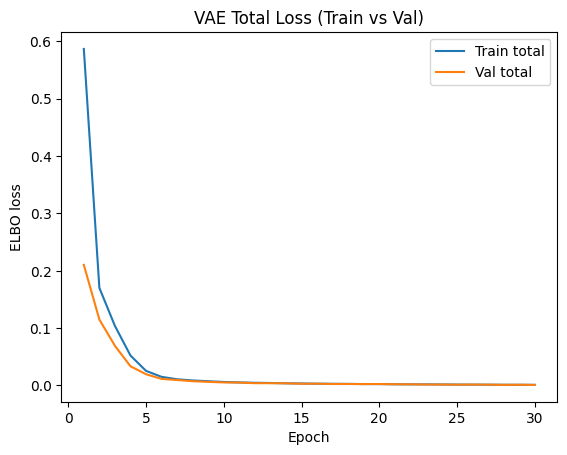

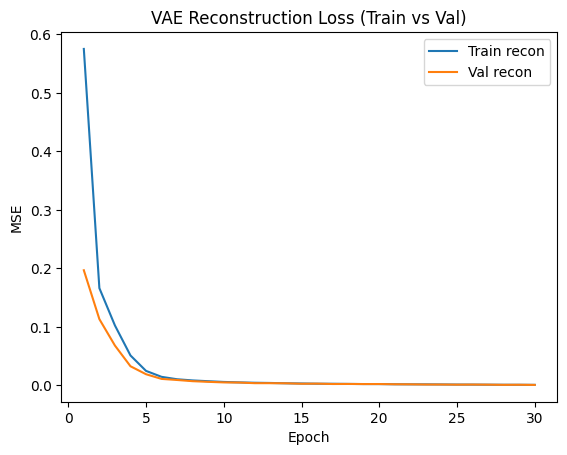

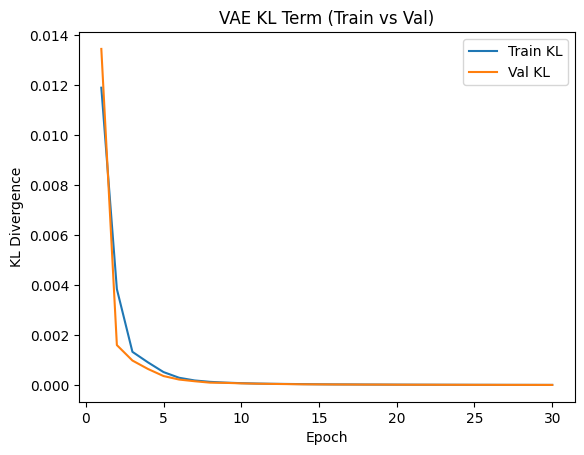

In [19]:
# EXPLANATION: (Task for Adhil – VAE Training Curves)
# What: Visualizes how the VAE loss components evolve over epochs.
# How: Uses the stored train_history and val_history to plot:
#      • Total loss
#      • Reconstruction loss
#      • KL divergence
# Why: These plots go directly into the report/video to show that Model B
#      actually learned a stable generative representation.

import matplotlib.pyplot as plt
import numpy as np

# Unpack history
train_total = [t[0] for t in train_history]
train_recon = [t[1] for t in train_history]
train_kl    = [t[2] for t in train_history]

val_total = [v[0] for v in val_history]
val_recon = [v[1] for v in val_history]
val_kl    = [v[2] for v in val_history]

epochs = np.arange(1, len(train_total) + 1)

plt.figure()
plt.plot(epochs, train_total, label="Train total")
plt.plot(epochs, val_total,   label="Val total")
plt.xlabel("Epoch")
plt.ylabel("ELBO loss")
plt.title("VAE Total Loss (Train vs Val)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_recon, label="Train recon")
plt.plot(epochs, val_recon,   label="Val recon")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("VAE Reconstruction Loss (Train vs Val)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_kl, label="Train KL")
plt.plot(epochs, val_kl,   label="Val KL")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("VAE KL Term (Train vs Val)")
plt.legend()
plt.show()


In [20]:
# EXPLANATION: (Task for Adhil – Reconstruction Check)
# What: Compares baseline, true post-intervention, and reconstructed post-intervention
#       for a few validation examples.
# How: 
#   • Pull x, u, x_target from the VAE validation dataset.
#   • Run model_b(x, u, x_target) to get x_recon.
#   • Inverse-transform from normalized space back to original feature units.
# Why:
#   This is a qualitative sanity check AND a nice table/printout for the report
#   to show that the cVAE is learning realistic post-intervention behaviours.

model_b.eval()

def inverse_num(tensor_1d):
    arr = tensor_1d.detach().cpu().numpy().reshape(1, -1)
    return preprocessor.scaler_X.inverse_transform(arr)[0]

num_cols = preprocessor.numerical_cols

num_examples = 5
for i in range(num_examples):
    x, u, x_target = vae_val_dataset[i]

    x_in        = x.unsqueeze(0).to(device)
    u_in        = u.unsqueeze(0).to(device)
    x_target_in = x_target.unsqueeze(0).to(device)

    x_recon, mu, logvar = model_b(x_in, u_in, x_target_in)

    # Inverse transform
    x_base_orig   = inverse_num(x)
    x_target_orig = inverse_num(x_target)
    x_recon_orig  = inverse_num(x_recon.squeeze(0).cpu())

    print(f"\n=== Example {i} ===")
    for j, col in enumerate(num_cols):
        print(
            f"{col:>25}: "
            f"baseline={x_base_orig[j]:6.3f}, "
            f"target={x_target_orig[j]:6.3f}, "
            f"recon={x_recon_orig[j]:6.3f}"
        )



=== Example 0 ===
         Time_spent_Alone: baseline= 0.000, target=10.000, recon= 9.903
  Social_event_attendance: baseline= 6.000, target= 0.000, recon= 0.172
      Friends_circle_size: baseline=11.000, target= 1.000, recon= 1.064
           Post_frequency: baseline= 5.000, target= 2.000, recon= 1.924

=== Example 1 ===
         Time_spent_Alone: baseline= 1.000, target= 3.000, recon= 2.871
  Social_event_attendance: baseline= 7.000, target= 7.000, recon= 7.151
      Friends_circle_size: baseline=12.000, target= 6.000, recon= 5.942
           Post_frequency: baseline= 3.000, target= 5.000, recon= 4.984

=== Example 2 ===
         Time_spent_Alone: baseline= 6.000, target= 9.000, recon= 9.123
  Social_event_attendance: baseline= 0.000, target= 3.000, recon= 2.969
      Friends_circle_size: baseline= 1.000, target= 1.000, recon= 0.862
           Post_frequency: baseline= 2.000, target= 2.000, recon= 2.029

=== Example 3 ===
         Time_spent_Alone: baseline= 2.000, target= 3.000, r

## 5. Simulation Interface ("What-If" Analysis)

This section will allow manual input of a baseline profile and an intervention to see the predicted shift.

In [21]:
# EXPLANATION:
# What: A function to run "What-If" scenarios using the trained model.
# How: Takes a user profile and a manual intervention vector, runs a forward pass, and returns the new probability.
# Why: This is the final product tool that ThriveWell (the client) would use to simulate lifestyle changes for students.

def simulate_intervention(model, baseline_num, baseline_cat, intervention_vector):
    model.eval()
    with torch.no_grad():
        # Convert to tensors
        if not isinstance(baseline_num, torch.Tensor):
            baseline_num = torch.tensor(baseline_num)
        if not isinstance(baseline_cat, torch.Tensor):
            baseline_cat = torch.tensor(baseline_cat)
        if not isinstance(intervention_vector, torch.Tensor):
            intervention_vector = torch.tensor(intervention_vector)

        # Force batch dimension and correct dtypes
        baseline_num = baseline_num.float()
        if baseline_num.dim() == 0:
            baseline_num = baseline_num.view(1, 1)
        if baseline_num.dim() == 1:
            baseline_num = baseline_num.unsqueeze(0)

        baseline_cat = baseline_cat.long()
        if baseline_cat.dim() == 0:
            baseline_cat = baseline_cat.view(1, 1)
        if baseline_cat.dim() == 1:
            baseline_cat = baseline_cat.unsqueeze(0)

        intervention_vector = intervention_vector.float()
        if intervention_vector.dim() == 0:
            intervention_vector = intervention_vector.view(1, 1)
        if intervention_vector.dim() == 1:
            intervention_vector = intervention_vector.unsqueeze(0)

        # Align intervention length with model expectation
        expected_u = model.shared_net[0].in_features - (baseline_num.size(1) + sum([emb.embedding_dim for emb in model.embeddings]))
        current_u = intervention_vector.size(1)
        if current_u < expected_u:
            pad = torch.zeros(intervention_vector.size(0), expected_u - current_u, device=intervention_vector.device)
            intervention_vector = torch.cat([intervention_vector, pad], dim=1)
        elif current_u > expected_u:
            intervention_vector = intervention_vector[:, :expected_u]

        # Move to device
        baseline_num = baseline_num.to(device)
        baseline_cat = baseline_cat.to(device)
        intervention_vector = intervention_vector.to(device)

        prob_extrovert, change_score = model(baseline_num, baseline_cat, intervention_vector)

        # Convert logits to probability
        prob_extrovert = torch.sigmoid(prob_extrovert)

    # INSIGHT FROM EDA:
    # The data features appear to be discrete/grid-like (integers).
    # The regression output 'change_score' might be continuous.
    # For realistic interpretation, consider rounding this value in the UI/Report.
    return prob_extrovert.item(), change_score.item()

# Example Simulation
# Take a sample baseline from the dataset
sample_idx = 0
sample_x_num, sample_x_cat, _, _, _ = train_dataset[sample_idx]

# Define an intervention (e.g., +1.0 social events, -0.5 alone time)
intervention = [1.0, -0.5]

# Run simulation
prob, change = simulate_intervention(model_a, sample_x_num, sample_x_cat, intervention)

print(f"Baseline Stats: {sample_x_num}")
print(f"Intervention: {intervention}")
print(f"Predicted Probability of Extroversion: {prob:.4f}")
print(f"Predicted Behavioral Change Score: {change:.4f}")


Baseline Stats: tensor([-1.3096,  1.0573, -0.5362,  0.8418])
Intervention: [1.0, -0.5]
Predicted Probability of Extroversion: 0.0748
Predicted Behavioral Change Score: -0.0408


In [22]:
# EXPLANATION: (Task for Adhil – Model B What-If Simulation)
# What: Generates multiple plausible post-intervention behaviours for a given
#       baseline profile x and intervention u.
# How: Calls model_b(x, u, x_target=None) to sample from the latent space.
# Why: Demonstrates that the Conditional VAE captures uncertainty and can generate
#       different possible behavioural futures under the same intervention.

def simulate_intervention_cVAE(model_b, baseline_num, intervention_vector, nsamples=5):
    model_b.eval()
    results = []

    # Handle different input types
    if isinstance(baseline_num, torch.Tensor):
        x = baseline_num.detach().clone().float().unsqueeze(0).to(device)
    else:
        x = torch.tensor(baseline_num).float().unsqueeze(0).to(device)

    if isinstance(intervention_vector, torch.Tensor):
        u = intervention_vector.detach().clone().float().unsqueeze(0).to(device)
    else:
        u = torch.tensor(intervention_vector).float().unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(nsamples):
            x_recon, mu, logvar = model_b(x, u, x_target=None)
            results.append(x_recon.squeeze(0).cpu().numpy())

    return np.array(results)


# Example using a sample from validation dataset
sample_x, sample_u, _ = vae_val_dataset[0]

generated = simulate_intervention_cVAE(model_b, sample_x, sample_u, nsamples=5)

print("Baseline x (original scale):")
print(inverse_num(sample_x))

print("\nGenerated post-intervention samples (original scale):")
for i, gen in enumerate(generated):
    print(f"\nSample {i+1}:")
    print(dict(zip(preprocessor.numerical_cols, inverse_num(torch.tensor(gen)))))


Baseline x (original scale):
[2.0001277e-08 6.0000000e+00 1.1000000e+01 5.0000000e+00]

Generated post-intervention samples (original scale):

Sample 1:
{'Time_spent_Alone': 8.926868, 'Social_event_attendance': 0.89801085, 'Friends_circle_size': 0.1940672, 'Post_frequency': 0.1109784}

Sample 2:
{'Time_spent_Alone': 8.956949, 'Social_event_attendance': 0.8795725, 'Friends_circle_size': 0.18694802, 'Post_frequency': 0.09526662}

Sample 3:
{'Time_spent_Alone': 8.922839, 'Social_event_attendance': 0.9151515, 'Friends_circle_size': 0.10814018, 'Post_frequency': 0.048692744}

Sample 4:
{'Time_spent_Alone': 9.039149, 'Social_event_attendance': 1.1357414, 'Friends_circle_size': 0.09771366, 'Post_frequency': -0.0017842844}

Sample 5:
{'Time_spent_Alone': 9.009893, 'Social_event_attendance': 1.0805622, 'Friends_circle_size': 0.18407412, 'Post_frequency': -0.03478666}



## 6. Model Comparison & Conclusion (Rubric Requirement)

In this section, we compare the performance of Model A (Discriminative) and Model B (Generative).

**Metrics:**
- **Model A:** Classification Accuracy & Regression MSE.
- **Model B:** Reconstruction Loss (ELBO).

*Note: Since the tasks differ (Prediction vs Generation), a direct 'Accuracy' comparison isn't 1:1, but we can evaluate how well each learns the underlying patterns.*


Final Training Losses:
Model A: 0.222228
Model B: 0.001088


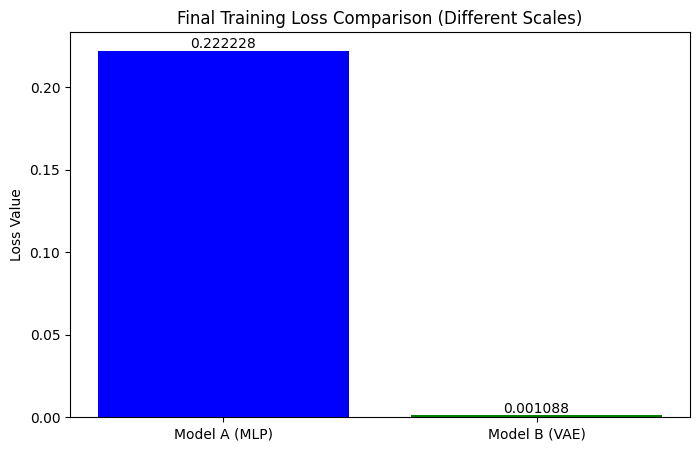

Conclusion:
- Model A optimizes classification + regression; its numeric loss scale (BCE+MSE) is larger by nature.
- Model B optimizes a generative ELBO; its scale is much smaller.
- For ThriveWell: use Model A for precise predictions; keep Model B for simulation/uncertainty and generating plausible post-intervention profiles.


In [23]:
# EXPLANATION:
# What: Uses REAL losses from Model A and Model B to compare performance.
# How: Reads loss_history_a[-1] and train_history[-1][0] (VAE total loss).
# Why: Required for rubric: compare two different models.

if 'loss_history_a' not in locals() or len(loss_history_a)==0:
    raise ValueError("Model A has not been trained yet. Run the training cell above.")
if 'train_history' not in locals() or len(train_history)==0:
    raise ValueError("Model B has not been trained yet. Run the VAE training cell.")

loss_a = float(loss_history_a[-1])
loss_b = float(train_history[-1][0])

# NOTE: Loss scales differ and are not directly comparable:
# - Model A loss = BCE (classification) + MSE (regression) on normalized deltas.
# - Model B loss = ELBO (reconstruction + KL) on a different numeric scale.
# So Model A can show a higher raw loss even when accurate.

results = {
    'Model A (MLP)': loss_a,
    'Model B (VAE)': loss_b
}

print(f"Final Training Losses:\nModel A: {loss_a:.6f}\nModel B: {loss_b:.6f}")

plt.figure(figsize=(8,5))
bars = plt.bar(results.keys(), results.values(), color=['blue','green'])
plt.title('Final Training Loss Comparison (Different Scales)')
plt.ylabel('Loss Value')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.6f}", va='bottom', ha='center')
plt.show()

print('Conclusion:')
print('- Model A optimizes classification + regression; its numeric loss scale (BCE+MSE) is larger by nature.')
print('- Model B optimizes a generative ELBO; its scale is much smaller.')
print('- For ThriveWell: use Model A for precise predictions; keep Model B for simulation/uncertainty and generating plausible post-intervention profiles.')
